In [ ]:
import os
import sys
import zipfile
import shutil
import numpy as np
import json
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from google.colab import drive
from tensorflow.keras import backend as K
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score, accuracy_score

In [ ]:
print("python:", sys.version)
print("tensorflow:", tf.version.VERSION)


python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
tensorflow: 2.20.0


In [ ]:
drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/AI/archive.zip'
extract_to = '/content/temp_dataset'

if not os.path.exists(extract_to):
    print("Extracting data...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print("Done.")

Mounted at /content/drive
Extracting data...
Done.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np

class SRMFilterLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(SRMFilterLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        #Filter 1: First-order horizontal edge detector
        filter_1 = np.array([
            [ 0,  0,  0],
            [-1,  1,  0],
            [ 0,  0,  0]
        ], dtype=np.float32)

        #Filter 2: Second-order Laplacian
        filter_2 = np.array([
            [ 0,  1,  0],
            [ 1, -4,  1],
            [ 0,  1,  0]
        ], dtype=np.float32)

        # Filter 3: Third-order SQUARE 5x5 high-pass (padded)
        # We use 3x3 for consistency this is a diagonal Laplacian variant
        filter_3 = np.array([
            [-1,  2, -1],
            [ 2, -4,  2],
            [-1,  2, -1]
        ], dtype=np.float32)

        # Stack into shape (3, 3, 1, 3) , 3 filters, each single-channel
        # We need to apply each filter to each of the 3 RGB channels
        # Final kernel shape: (3, 3, 3, 3) -> 3x3 kernel, 3 input channels, 3 output filters
        stacked = np.stack([filter_1, filter_2, filter_3], axis=-1)  # (3, 3, 3)

        # Expand for 3 input channels: apply same filter to each channel
        num_input_channels = input_shape[-1]  # should be 3 for RGB
        kernel = np.zeros((3, 3, num_input_channels, 3), dtype=np.float32)
        for i in range(3):  # for each filter
            for c in range(num_input_channels):  # for each input channel
                kernel[:, :, c, i] = stacked[:, :, i]

        # Normalize each filter
        for i in range(3):
            norm = np.sum(np.abs(kernel[:, :, :, i]))
            if norm > 0:
                kernel[:, :, :, i] /= norm

        self.srm_kernel = self.add_weight(
            name='srm_filters',
            shape=kernel.shape,
            initializer=tf.keras.initializers.Constant(kernel),
            trainable=False  # CRITICAL: These filters must NOT be trained
        )

        super(SRMFilterLayer, self).build(input_shape)

    def call(self, inputs):
        noise_residual = tf.nn.conv2d(
            inputs, self.srm_kernel, strides=[1, 1, 1, 1], padding='SAME'
        )
        noise_residual = tf.clip_by_value(noise_residual, -3.0, 3.0)
        return noise_residual

    def get_config(self):
        config = super(SRMFilterLayer, self).get_config()
        return config

print("SRMFilterLayer defined successfully.")
print("This layer extracts forensic noise residuals using 3 fixed high-pass filters.")


SRMFilterLayer defined successfully.
This layer extracts forensic noise residuals using 3 fixed high-pass filters.


Found 100000 files belonging to 2 classes.
Found 20000 files belonging to 2 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

 Two-Stream Architecture Built Successfully
   Stream A (RGB):      MobileNetV2 → GAP → 1280-d vector
   Stream B (Forensic): SRM Filters → 3×Conv2D → GAP → 128-d vector
   Fusion:              Concatenate → Dense(256) → Dropout → Sigmoid


Model: "TwoStream_SRM_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ srm_filter          │ (None, 224, 224,  │         81 │ input_image[0][0] │
│ (SRMFilterLayer)    │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ srm_conv1 (Conv2D)  │ (None, 224, 224,  │        896 │ srm_filter[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ srm_bn1             │ (None, 224, 224,  │        128 │ srm_conv1[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ srm_pool1           │ (None, 112, 112,  │          0 │ srm_bn1[0][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ srm_conv2 (Conv2D)  │ (None, 112, 112,  │     18,496 │ srm_pool1[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ srm_bn2             │ (None, 112, 112,  │        256 │ srm_conv2[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ srm_pool2           │ (None, 56, 56,    │          0 │ srm_bn2[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ srm_conv3 (Conv2D)  │ (None, 56, 56,    │     73,856 │ srm_pool2[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ input_image[0][0] │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ srm_bn3             │ (None, 56, 56,    │        512 │ srm_conv3[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rgb_gap             │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ srm_gap             │ (None, 128)       │          0 │ srm_bn3[0][0]     │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stream_merge        │ (None, 1408)      │          0 │ rgb_gap[0][0],    │
│ (Concatenate)       │                   │            │ srm_gap[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_dense (Dense)  │ (None, 256)       │    360,704 │ stream_merge[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_bn             │ (None, 256)       │      1,024 │ head_dense[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_dropout        │ (None, 256)       │          0 │ head_bn[0][0]     │
│ (Dropout)           │                   │            │                 

 Total params: 2,714,194 (10.35 MB)

 Trainable params: 455,169 (1.74 MB)

...


Epoch 12: finished saving model to /content/drive/MyDrive/best_model_twostream3.h5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 229s 73ms/step - accuracy: 0.9980 - loss: 0.0070 - val_accuracy: 0.9961 - val_loss: 0.0119 - learning_rate: 1.0000e-05
Epoch 13/25
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9981 - loss: 0.0069
Epoch 13: val_accuracy improved from 0.99605 to 0.99615, saving model to /content/drive/MyDrive/best_model_twostream3.h5



Epoch 13: finished saving model to /content/drive/MyDrive/best_model_twostream3.h5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 227s 73ms/step - accuracy: 0.9979 - loss: 0.0071 - val_accuracy: 0.9962 - val_loss: 0.0109 - learning_rate: 1.0000e-05
Epoch 14/25
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9985 - loss: 0.0055
Epoch 14: val_accuracy did not improve from 0.99615
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 226s 72ms/step - accuracy: 0.9985 - loss: 0.0055 - val_accuracy: 0.9961 - val_loss: 0.0117 - learning_rate: 1.0000e-05
Epoch 15/25
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9984 - loss: 0.0051
Epoch 15: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.

Epoch 15: val_accuracy improved from 0.99615 to 0.99625, saving model to /content/drive/MyDrive/best_model_twostream3.h5



Epoch 15: finished saving model to /content/drive/MyDrive/best_model_twostream3.h5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 228s 73ms/step - accuracy: 0.9983 - loss: 0.0058 - val_accuracy: 0.9962 - val_loss: 0.0111 - learning_rate: 1.0000e-05
Epoch 16/25
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9987 - loss: 0.0046
Epoch 16: val_accuracy improved from 0.99625 to 0.99655, saving model to /content/drive/MyDrive/best_model_twostream3.h5



Epoch 16: finished saving model to /content/drive/MyDrive/best_model_twostream3.h5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 228s 73ms/step - accuracy: 0.9989 - loss: 0.0044 - val_accuracy: 0.9966 - val_loss: 0.0106 - learning_rate: 5.0000e-06
Epoch 17/25
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9988 - loss: 0.0042
Epoch 17: val_accuracy improved from 0.99655 to 0.99660, saving model to /content/drive/MyDrive/best_model_twostream3.h5



Epoch 17: finished saving model to /content/drive/MyDrive/best_model_twostream3.h5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 228s 73ms/step - accuracy: 0.9990 - loss: 0.0040 - val_accuracy: 0.9966 - val_loss: 0.0102 - learning_rate: 5.0000e-06
Epoch 18/25
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9991 - loss: 0.0035
Epoch 18: val_accuracy did not improve from 0.99660
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 226s 72ms/step - accuracy: 0.9993 - loss: 0.0030 - val_accuracy: 0.9962 - val_loss: 0.0103 - learning_rate: 5.0000e-06
Epoch 19/25
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9989 - loss: 0.0036
Epoch 19: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.

Epoch 19: val_accuracy did not improve from 0.99660
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 225s 72ms/step - accuracy: 0.9991 - loss: 0.0033 - val_accuracy: 0.9965 - val_loss: 0.0102 - learning_rate: 5.0000e-06
Epoch 20/25
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9993 - loss: 0.0031
Epoch 20: val_

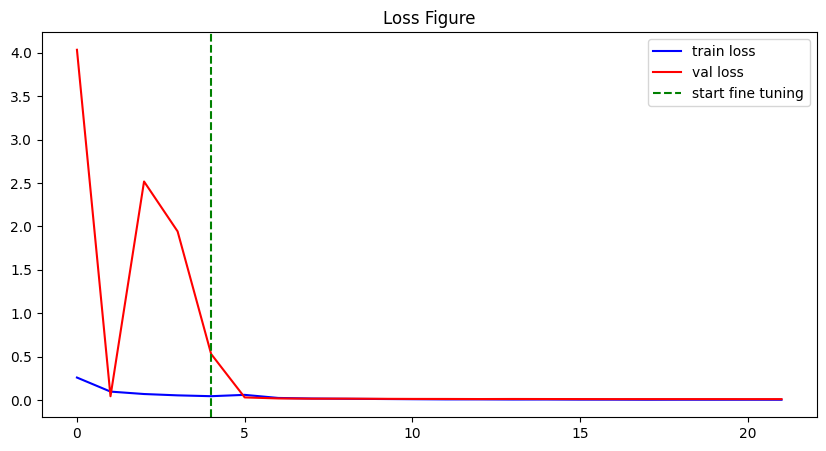

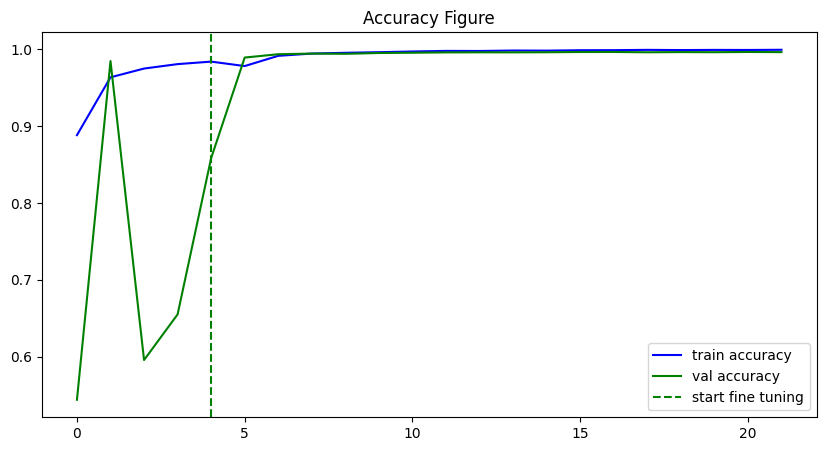


Generating Final Detailed Report...


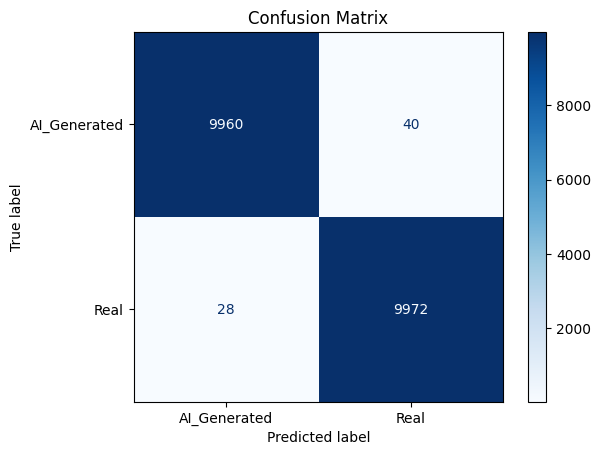

Final Model Results
Average Warm-Up Acc      : 95.84%
Average Warm-Up Val Acc  : 72.76%
Average Fine-Tune Acc    : 99.65%
Average Fine-Tune Val Acc: 99.54%
--------------------------------------------------
 Average Acc      : 98.78%
 Average Val Acc  : 93.46%
Total Accuracy (Eval)    : 99.6600%
Total Loss (Eval)        : 0.0102
--------------------------------------------------
AI_Generated Precision   : 99.72%
Real Precision           : 99.60%
Final model saved to Google Drive: /content/drive/MyDrive/Deepfake_TwoStream3_Final.h5


In [ ]:
# 1) Setup data and params
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
TRAIN_DIR = '/content/temp_dataset/archive/real_vs_AI_Generated/real-vs-AI_Generated/train'
VAL_DIR = '/content/temp_dataset/archive/real_vs_AI_Generated/real-vs-AI_Generated/valid'

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    label_mode='binary'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    label_mode='binary'
)

# 2) Simple augmentation to prevent overfitting
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# 3) Building the MobileNet model
inputs = tf.keras.Input(shape=IMG_SIZE + (3,), name='input_image')

# STREAM A: RGB Stream (MobileNetV2)
# BULLETPROOF FIX: Call MobileNetV2 directly from tf.keras
base_model = tf.keras.applications.MobileNetV2(weights="imagenet", include_top=False, input_shape=IMG_SIZE + (3,))
base_model.trainable = False
base_model._name = 'mobilenetv2_rgb'  # Explicit name for Grad-CAM targeting

stream_a = base_model(inputs, training=False)
stream_a = layers.GlobalAveragePooling2D(name='rgb_gap')(stream_a)
# Output: (batch, 1280)

# STREAM B: Forensic/SRM Noise Stream
noise = SRMFilterLayer(name='srm_filter')(inputs)

#1
noise = layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='srm_conv1')(noise)
noise = layers.BatchNormalization(name='srm_bn1')(noise)
noise = layers.MaxPooling2D((2, 2), name='srm_pool1')(noise)

#2
noise = layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='srm_conv2')(noise)
noise = layers.BatchNormalization(name='srm_bn2')(noise)
noise = layers.MaxPooling2D((2, 2), name='srm_pool2')(noise)

#3
noise = layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='srm_conv3')(noise)
noise = layers.BatchNormalization(name='srm_bn3')(noise)
noise = layers.GlobalAveragePooling2D(name='srm_gap')(noise)

# Output: (batch, 128)
merged = layers.Concatenate(name='stream_merge')([stream_a, noise])

x = layers.Dense(256, activation='relu', name='head_dense')(merged)
x = layers.BatchNormalization(name='head_bn')(x)
x = layers.Dropout(0.4, name='head_dropout')(x)
output = layers.Dense(1, activation='sigmoid', name='head_output')(x)

final_model = models.Model(inputs=inputs, outputs=output, name='TwoStream_SRM_MobileNetV2')

print("\n Two-Stream Architecture Built Successfully")
print("   Stream A (RGB):      MobileNetV2 → GAP → 1280-d vector")
print("   Stream B (Forensic): SRM Filters → 3×Conv2D → GAP → 128-d vector")
print("   Fusion:              Concatenate → Dense(256) → Dropout → Sigmoid")
final_model.summary()


# 4) Phase 1: Warm up
print("\n Phase: Warm Up")
final_model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                    loss='binary_crossentropy', metrics=['accuracy'])
history_warmup = final_model.fit(train_ds, epochs=5, validation_data=val_ds)

# 5) Phase 2: Fine-tuning
print("\n Phase: Fine-Tuning")
base_model.trainable = True
for layer in base_model.layers[:-100]:
    layer.trainable = False

final_model.compile(optimizer=optimizers.Adam(learning_rate=1e-5), loss='binary_crossentropy', metrics=['accuracy'])

callbacks_list = [
    EarlyStopping(patience=5, monitor='val_accuracy', restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1),
    ModelCheckpoint('/content/drive/MyDrive/best_model_twostream3.h5', save_best_only=True, monitor='val_accuracy', verbose=1)
]

history_finetune = final_model.fit(
    train_ds, epochs=25, initial_epoch=history_warmup.epoch[-1] + 1,
    validation_data=val_ds, callbacks=callbacks_list
)

# 6) Getting the history for the plots
acc = history_warmup.history['accuracy'] + history_finetune.history['accuracy']
val_acc = history_warmup.history['val_accuracy'] + history_finetune.history['val_accuracy']
loss = history_warmup.history['loss'] + history_finetune.history['loss']
val_loss = history_warmup.history['val_loss'] + history_finetune.history['val_loss']

#Loss
plt.figure(figsize=(10, 5))
plt.plot(loss, label='train loss', color='blue')
plt.plot(val_loss, label='val loss', color='red')
plt.axvline(x=4, color='green', linestyle='--', label='start fine tuning')
plt.title('Loss Figure')
plt.legend()
plt.show()

# Accuracy
plt.figure(figsize=(10, 5))
plt.plot(acc, label='train accuracy', color='blue')
plt.plot(val_acc, label='val accuracy', color='green')
plt.axvline(x=4, color='green', linestyle='--', label='start fine tuning')
plt.title('Accuracy Figure')
plt.legend()
plt.show()

# 7) Final evaluation report
print("\nGenerating Final Detailed Report...")
val_ds_clean = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR, shuffle=False,
    batch_size=32,
    image_size=(224, 224),
    label_mode='binary',
    verbose=0
)

# val_ds_clean = val_ds_clean.map(lambda x, y: (preprocess_input(x), y))

results = final_model.evaluate(val_ds_clean, verbose=0)
loss_final = results[0]
acc_final = results[1]

y_pred_probs = final_model.predict(val_ds_clean, verbose=0)
y_pred = (y_pred_probs > 0.5).astype(int)

y_true = np.concatenate([y for x, y in val_ds_clean], axis=0)

report = classification_report(y_true, y_pred,
                               target_names=['AI_Generated', 'Real'],
                               output_dict=True)

# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['AI_Generated', 'Real'])

disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

avg_warmup_acc = np.mean(history_warmup.history['accuracy']) * 100
avg_warmup_val_acc = np.mean(history_warmup.history['val_accuracy']) * 100

avg_finetune_acc = np.mean(history_finetune.history['accuracy']) * 100
avg_finetune_val_acc = np.mean(history_finetune.history['val_accuracy']) * 100

avg_total_acc = np.mean(acc) * 100
avg_total_val_acc = np.mean(val_acc) * 100

print("Final Model Results")
print(f"Average Warm-Up Acc      : {avg_warmup_acc:.2f}%")
print(f"Average Warm-Up Val Acc  : {avg_warmup_val_acc:.2f}%")
print(f"Average Fine-Tune Acc    : {avg_finetune_acc:.2f}%")
print(f"Average Fine-Tune Val Acc: {avg_finetune_val_acc:.2f}%")
print("-" * 50)
print(f" Average Acc      : {avg_total_acc:.2f}%")
print(f" Average Val Acc  : {avg_total_val_acc:.2f}%")
print(f"Total Accuracy (Eval)    : {acc_final * 100:.4f}%")
print(f"Total Loss (Eval)        : {loss_final:.4f}")
print("-" * 50)
print(f"AI_Generated Precision   : {report['AI_Generated']['precision']*100:.2f}%")
print(f"Real Precision           : {report['Real']['precision']*100:.2f}%")


final_model.save("/content/drive/MyDrive/Deepfake_TwoStream3_Final.h5")
print("Final model saved to Google Drive: /content/drive/MyDrive/Deepfake_TwoStream3_Final.h5")

In [ ]:
import tensorflow as tf
import numpy as np
from sklearn.metrics import classification_report
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input


VAL_DIR = '/content/temp_dataset/archive/real_vs_AI_Generated/real-vs-AI_Generated/valid'

print("Loading validation data...")
val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR, shuffle=False, batch_size=32, image_size=(224, 224), label_mode='binary', verbose=0
)
#val_ds_clean = val_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds_clean = val_ds

print("Loading Two-Stream Model from Drive")
model = tf.keras.models.load_model(
    '/content/drive/MyDrive/Deepfake_TwoStream3_Final.h5',
    custom_objects={'SRMFilterLayer': SRMFilterLayer}
)

print("Evaluating model...")
results = model.evaluate(val_ds_clean, verbose=0)
loss_final = results[0]
acc_final = results[1]

print("Generating predictions...")
y_pred_probs = model.predict(val_ds_clean, verbose=0)
y_pred = (y_pred_probs > 0.5).astype(int)
y_true = np.concatenate([y for x, y in val_ds_clean], axis=0)

print("FINAL PERFORMANCE SUMMARY")
print("-"*50)
print(f"Total Validation Accuracy : {acc_final * 100:.4f}%")
print(f"Total Validation Loss     : {loss_final:.4f}")
print("Detailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=['AI_Generated', 'Real'], digits=4))


Loading validation data...
Loading Two-Stream Model from Drive


Evaluating model...
Generating predictions...
FINAL PERFORMANCE SUMMARY
--------------------------------------------------
Total Validation Accuracy : 99.6600%
Total Validation Loss     : 0.0102
Detailed Classification Report:
              precision    recall  f1-score   support

AI_Generated     0.9972    0.9960    0.9966     10000
        Real     0.9960    0.9972    0.9966     10000

    accuracy                         0.9966     20000
   macro avg     0.9966    0.9966    0.9966     20000
weighted avg     0.9966    0.9966    0.9966     20000



Model loaded successfully!
Getting predictions...
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step


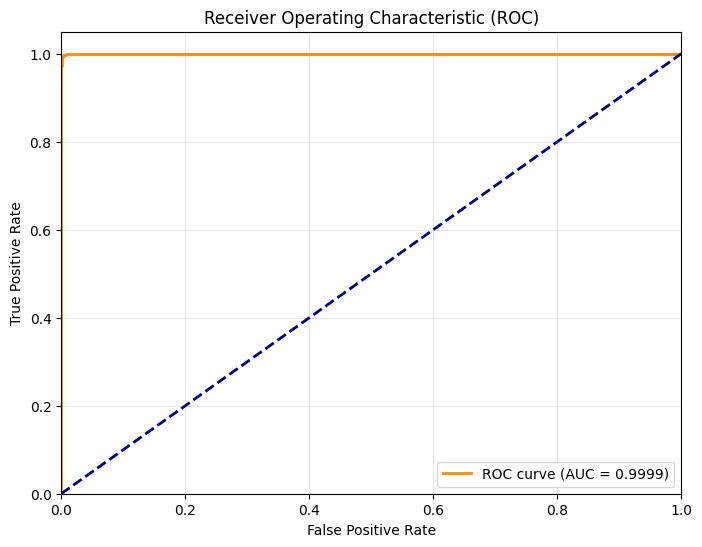

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import tensorflow as tf
from tensorflow.keras import models

# 1) Load the trained model
MODEL_PATH = '/content/drive/MyDrive/Deepfake_TwoStream3_Final.h5'

# Pass SRMFilterLayer
final_model = models.load_model(MODEL_PATH, custom_objects={'SRMFilterLayer': SRMFilterLayer})
print("Model loaded successfully!")

VAL_DIR = '/content/temp_dataset/archive/real_vs_AI_Generated/real-vs-AI_Generated/valid'
val_ds_clean = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR, shuffle=False,
    batch_size=32,
    image_size=(224, 224),
    label_mode='binary',
    verbose=0
)

# 3) Get predictions & true labels
print("Getting predictions...")
y_pred_probs = final_model.predict(val_ds_clean, verbose=1)
y_true = np.concatenate([y for x, y in val_ds_clean], axis=0)

# 4) Calculate ROC & AUC
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

# 5) Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import os
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, accuracy_score
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# 1) Setup Test Data Path
TEST_DIR = '/content/temp_dataset/archive/real_vs_AI_Generated/real-vs-AI_Generated/test'

print("Loading test data...")
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    shuffle=False,
    batch_size=32,
    image_size=(224, 224),
    label_mode='binary',
    verbose=0
)
#test_ds_clean = test_ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=tf.data.AUTOTUNE)
test_ds_clean = test_ds

# 2) Load Model from Kaggle Working Directory
print("Loading Two-Stream Model.")
model_path = '/content/drive/MyDrive/Deepfake_TwoStream3_Final.h5'

if os.path.exists(model_path):
    model = tf.keras.models.load_model(model_path, custom_objects={'SRMFilterLayer': SRMFilterLayer})
    print(f"Successfully loaded model from: {model_path}")
else:
    print("ERROR: Model file not found.")

# 3) Predictions
print("Generating predictions on unseen test data...")
y_pred_probs = model.predict(test_ds_clean, verbose=1)
y_pred = (y_pred_probs > 0.5).astype(int)

y_true = np.concatenate([y for x, y in test_ds_clean], axis=0)

# 4) Professional Output Report
print("\n" + "="*50)
print("FINAL PERFORMANCE SUMMARY: UNSEEN TEST DATA")
print("="*50)
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=['AI_Generated', 'Real'], digits=4))

test_acc = accuracy_score(y_true, y_pred) * 100
print("-" * 50)
print(f"Overall Test Accuracy: {test_acc:.2f}%")
print("="*50)

Loading test data...
Loading Two-Stream Model.


Successfully loaded model from: /content/drive/MyDrive/Deepfake_TwoStream3_Final.h5
Generating predictions on unseen test data...
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step

FINAL PERFORMANCE SUMMARY: UNSEEN TEST DATA
Classification Report:
              precision    recall  f1-score   support

AI_Generated     0.9963    0.9949    0.9956     10000
        Real     0.9949    0.9963    0.9956     10000

    accuracy                         0.9956     20000
   macro avg     0.9956    0.9956    0.9956     20000
weighted avg     0.9956    0.9956    0.9956     20000

--------------------------------------------------
Overall Test Accuracy: 99.56%


Loading Model...


Saving XJEUHJT4D6.jpg to XJEUHJT4D6.jpg

------------------------
Prediction: AI GENERATED
Confidence: 0.9999997545723716
------------------------


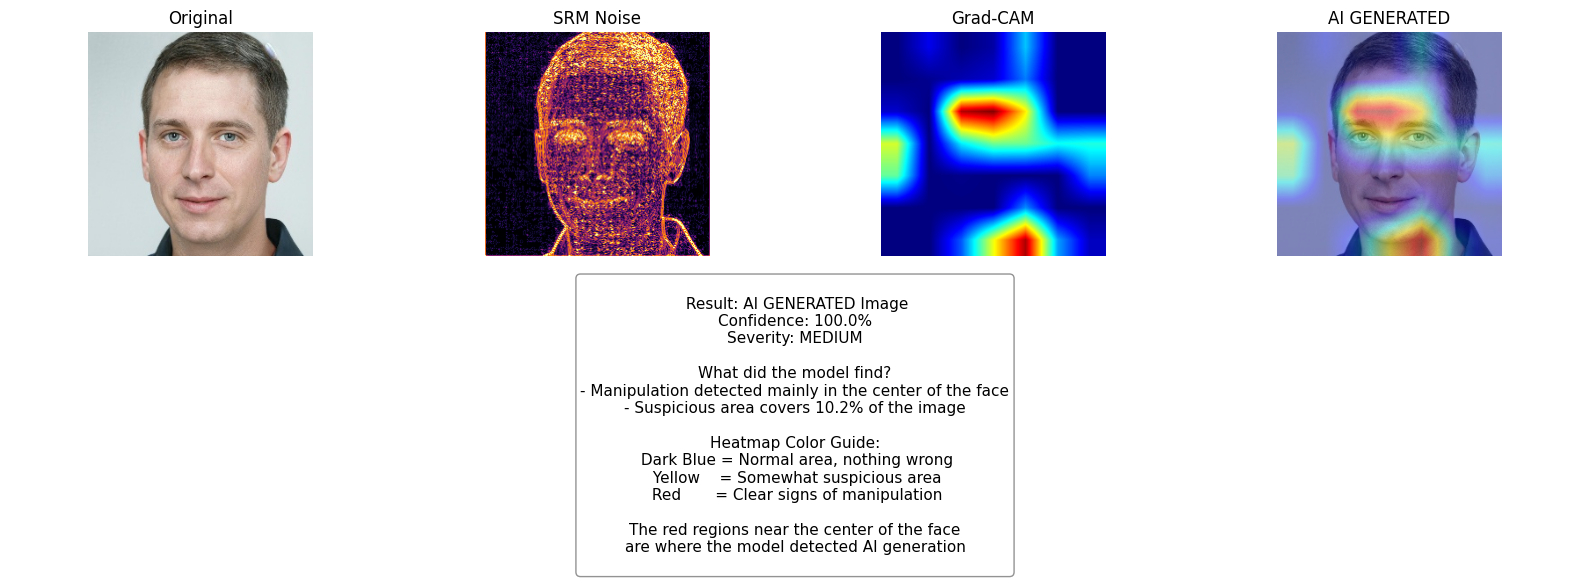

In [ ]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files


# 1) SRM Layer
class SRMFilterLayer(tf.keras.layers.Layer):
    def init(self, **kwargs):
        super(SRMFilterLayer, self).init(**kwargs)

    def build(self, input_shape):
        filter_1 = np.array([[0,0,0],[-1,1,0],[0,0,0]], dtype=np.float32)
        filter_2 = np.array([[0,1,0],[1,-4,1],[0,1,0]], dtype=np.float32)
        filter_3 = np.array([[-1,2,-1],[2,-4,2],[-1,2,-1]], dtype=np.float32)

        stacked = np.stack([filter_1, filter_2, filter_3], axis=-1)

        num_input_channels = input_shape[-1]
        kernel = np.zeros((3,3,num_input_channels,3), dtype=np.float32)

        for i in range(3):
            for c in range(num_input_channels):
                kernel[:,:,c,i] = stacked[:,:,i]

        for i in range(3):
            norm = np.sum(np.abs(kernel[:,:,:,i]))
            if norm > 0:
                kernel[:,:,:,i] /= norm

        self.srm_kernel = self.add_weight(
            name='srm_filters',
            shape=kernel.shape,
            initializer=tf.keras.initializers.Constant(kernel),
            trainable=False
        )
        super(SRMFilterLayer, self).build(input_shape)

    def call(self, inputs):
        noise = tf.nn.conv2d(inputs, self.srm_kernel, strides=1, padding='SAME')
        return tf.clip_by_value(noise, -3.0, 3.0)


# 2) Load Model
print("Loading Model...")
model_path = '/content/drive/MyDrive/Deepfake_TwoStream3_Final.h5'

model = tf.keras.models.load_model(
    model_path,
    custom_objects={'SRMFilterLayer': SRMFilterLayer}
)

IMG_SIZE = (224, 224)


# 3) Layers
mobilenet_layer = [l for l in model.layers if 'mobilenet' in l.name.lower()][0]
rgb_gap_layer = model.get_layer('rgb_gap')
stream_merge = model.get_layer('stream_merge')
head_dense = model.get_layer('head_dense')
head_bn = model.get_layer('head_bn')
head_dropout = model.get_layer('head_dropout')
head_output = model.get_layer('head_output')

srm_branch = tf.keras.Model(model.input, model.get_layer('srm_gap').output)
srm_vis_model = tf.keras.Model(model.input, model.get_layer('srm_filter').output)


# 4) Image prep
def prepare_image(path):
    img = cv2.imread(path)
    if img is None:
        raise ValueError("Image not found")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    original = img.copy()

    img = cv2.resize(img, IMG_SIZE)
    img = np.expand_dims(img.astype(np.float32), axis=0)

    return original, tf.convert_to_tensor(img)


# 5) GradCAM
def make_gradcam(img_tensor):

    srm_vec = srm_branch(img_tensor, training=False)

    with tf.GradientTape() as tape:
        features = mobilenet_layer(img_tensor, training=False)
        tape.watch(features)

        rgb_vec = rgb_gap_layer(features)
        merged = stream_merge([rgb_vec, srm_vec])

        x = head_dense(merged)
        x = head_bn(x, training=False)
        x = head_dropout(x, training=False)
        preds = head_output(x)

        score = preds[0,0]

    grads = tape.gradient(score, features)

    pooled = tf.reduce_mean(grads, axis=(0,1,2))
    features = features[0]

    heatmap = tf.reduce_sum(features * pooled, axis=-1)
    heatmap = tf.maximum(heatmap, 0)

    if tf.reduce_max(heatmap) > 0:
        heatmap /= tf.reduce_max(heatmap)

    return heatmap.numpy()


# 6) SRM noise
def get_srm_noise(img_tensor):
    noise = srm_vis_model(img_tensor, training=False).numpy()[0]
    noise = np.mean(np.abs(noise), axis=-1)

    noise = (noise - noise.min()) / (noise.max() - noise.min() + 1e-8)
    return noise


# 7) overlay
def overlay_heatmap(original, heatmap):

    heatmap = cv2.resize(heatmap, (original.shape[1], original.shape[0]))

    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    return heatmap, cv2.addWeighted(original, 0.6, heatmap, 0.4, 0)


# 8) prediction
def explain(score):
    if score > 0.5:
        return "REAL", score, f"Real: {score*100:.2f}% | AI: {(1-score)*100:.2f}%"
    else:
        return "AI GENERATED", 1-score, f"AI: {(1-score)*100:.2f}% | Real: {score*100:.2f}%"


# 9) Smart explanation
def generate_smart_explanation(heatmap, label, conf):
    h, w = heatmap.shape
    high = heatmap > 0.6
    ratio = np.sum(high) / heatmap.size

    regions = {
        "left side of the face": np.sum(high[:, :w//3]),
        "center of the face": np.sum(high[:, w//3:2*w//3]),
        "right side of the face": np.sum(high[:, 2*w//3:])
    }
    main_region = max(regions, key=regions.get)

    if label == "REAL":
        if ratio > 0.1:
            heatmap_note = f"""⚠️ Note: The heatmap shows some activation
→ Model is confident it's real, but pay attention
→ Suspicious area: {ratio*100:.1f}% of the image
→ Focus region: {main_region}"""
        else:
            heatmap_note = """Your heatmap is fully dark blue
→ The model found zero suspicious regions"""

        return f"""
 Result: REAL Image
Confidence: {conf*100:.1f}%

Why is it real?
- No pixel manipulation was detected
- Colors and gradients look natural
- No AI generation artifacts found

Heatmap Color Guide:
 Dark Blue = Nothing suspicious here
 Yellow    = Slightly unusual area
 Red       = Highly suspicious area

{heatmap_note}
"""

    else:
        if ratio > 0.3:
            detail = "Manipulation covers most of the image"
            severity = "HIGH"
        elif ratio > 0.1:
            detail = f"Manipulation detected mainly in the {main_region}"
            severity = "MEDIUM"
        else:
            detail = f"Subtle traces found near the {main_region}"
            severity = "LOW"

        return f"""
 Result: AI GENERATED Image
Confidence: {conf*100:.1f}%
Severity: {severity}

What did the model find?
- {detail}
- Suspicious area covers {ratio*100:.1f}% of the image

Heatmap Color Guide:
 Dark Blue = Normal area, nothing wrong
 Yellow    = Somewhat suspicious area
 Red       = Clear signs of manipulation

The red regions near the {main_region}
are where the model detected AI generation
"""


# 10) MAIN
def predict_and_visualize(path):

    original, img_tensor = prepare_image(path)

    score = float(model.predict(img_tensor, verbose=0)[0][0])
    label, conf, details = explain(score)

    heatmap = make_gradcam(img_tensor)
    noise = get_srm_noise(img_tensor)
    heatmap_overlay, overlay = overlay_heatmap(original, heatmap)

    smart_text = generate_smart_explanation(heatmap, label, conf)

    print("\n------------------------")
    print("Prediction:", label)
    print("Confidence:", conf)
    print("------------------------")

    plt.figure(figsize=(16,6))

    plt.subplot(2,4,1)
    plt.imshow(original)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2,4,2)
    plt.imshow(noise, cmap="inferno")
    plt.title("SRM Noise")
    plt.axis("off")

    plt.subplot(2,4,3)
    plt.imshow(heatmap_overlay)
    plt.title("Grad-CAM")
    plt.axis("off")

    plt.subplot(2,4,4)
    plt.imshow(overlay)
    plt.title(label)
    plt.axis("off")

    plt.subplot(2,1,2)
    plt.text(
        0.5,
        0.5,
        smart_text,
        ha="center",
        va="center",
        fontsize=11,
        bbox=dict(
            facecolor='white',
            alpha=0.85,
            edgecolor='gray',
            boxstyle='round'
        )
    )
    plt.axis("off")

    plt.tight_layout()
    plt.show()


# 11) Upload
def upload_and_predict():
    uploaded = files.upload()

    for name in uploaded.keys():
        predict_and_visualize(name)


upload_and_predict()